In [1]:
import zipfile
import pandas as pd
import numpy as np
import os

import polyscope as ps

In [2]:

paths = ["../local/BALBc_no1_raw.zip",
        "../local/BALBc_no2_raw.zip",
        "../local/BALBc_no3_raw.zip"]

all_data : dict[list[pd.DataFrame]] = {}

for path in paths:

    dataFrames : list[pd.DataFrame] = []

    with zipfile.ZipFile(path) as z:
        print("File list: ", z.namelist())

        for name in z.namelist():
            if name.endswith(".csv"):

                with z.open(name) as f:
                    df = pd.read_csv(f, sep=";")

                dataFrames.append(df)
    
    all_data[z.namelist()[0].rstrip("/")] = dataFrames
    print(f"Added {path}...")


File list:  ['BALBc_no1_raw/', 'BALBc_no1_raw/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0_nodes.csv', 'BALBc_no1_raw/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0_edges.csv']
Added ../local/BALBc_no1_raw.zip...
File list:  ['BALBc_no2_raw/', 'BALBc_no2_raw/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0_edges.csv', 'BALBc_no2_raw/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0_nodes.csv']
Added ../local/BALBc_no2_raw.zip...
File list:  ['BALBc_no3_raw/', 'BALBc_no3_raw/BALBc-no3_iso3um_stitched_segmentation_bulge_size_3.0_edges.csv', 'BALBc_no3_raw/BALBc-no3_iso3um_stitched_segmentation_bulge_size_3.0_nodes.csv']
Added ../local/BALBc_no3_raw.zip...


In [3]:
print("All raw data size: ", len(all_data))
for i in all_data:
    print(i, "size:", len(all_data[i]))

All raw data size:  3
BALBc_no1_raw size: 2
BALBc_no2_raw size: 2
BALBc_no3_raw size: 2


In [4]:
for i in all_data:
    print(f"========={i} ==========")
    for j in all_data[i]:
        print("------dataFrame------")
        print(j.info(), "\n")

=========BALBc_no1_raw ==========
------dataFrame------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3538495 entries, 0 to 3538494
Data columns (total 6 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                int64  
 1   pos_x             float64
 2   pos_y             float64
 3   pos_z             float64
 4   degree            int64  
 5   isAtSampleBorder  int64  
dtypes: float64(3), int64(3)
memory usage: 162.0 MB
None 

------dataFrame------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5409812 entries, 0 to 5409811
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   node1id                int64  
 2   node2id                int64  
 3   length                 float64
 4   distance               float64
 5   curveness              float64
 6   volume                 int64  
 7   avgCrossSection        float64
 8   minRadiusAvg           fl

In [5]:
BALBc_1_1 : pd.DataFrame = all_data["BALBc_no1_raw"][0]
BALBc_1_2 : pd.DataFrame = all_data["BALBc_no1_raw"][1]
BALBc_2_1 : pd.DataFrame = all_data["BALBc_no2_raw"][0]
BALBc_2_2 : pd.DataFrame = all_data["BALBc_no2_raw"][1]
BALBc_3_1 : pd.DataFrame = all_data["BALBc_no3_raw"][0]
BALBc_3_2 : pd.DataFrame = all_data["BALBc_no3_raw"][1]
print("BALBc_1:", BALBc_1_1.columns)
print("BALBc_1:", BALBc_1_2.columns)
print("BALBc_2:", BALBc_2_1.columns)
print("BALBc_2:", BALBc_2_2.columns)
print("BALBc_3:", BALBc_3_1.columns)
print("BALBc_3:", BALBc_3_2.columns)

BALBc_1: Index(['id', 'pos_x', 'pos_y', 'pos_z', 'degree', 'isAtSampleBorder'], dtype='object')
BALBc_1: Index(['id', 'node1id', 'node2id', 'length', 'distance', 'curveness', 'volume',
       'avgCrossSection', 'minRadiusAvg', 'minRadiusStd', 'avgRadiusAvg',
       'avgRadiusStd', 'maxRadiusAvg', 'maxRadiusStd', 'roundnessAvg',
       'roundnessStd', 'node1_degree', 'node2_degree', 'num_voxels',
       'hasNodeAtSampleBorder'],
      dtype='object')
BALBc_2: Index(['id', 'node1id', 'node2id', 'length', 'distance', 'curveness', 'volume',
       'avgCrossSection', 'minRadiusAvg', 'minRadiusStd', 'avgRadiusAvg',
       'avgRadiusStd', 'maxRadiusAvg', 'maxRadiusStd', 'roundnessAvg',
       'roundnessStd', 'node1_degree', 'node2_degree', 'num_voxels',
       'hasNodeAtSampleBorder'],
      dtype='object')
BALBc_2: Index(['id', 'pos_x', 'pos_y', 'pos_z', 'degree', 'isAtSampleBorder'], dtype='object')
BALBc_3: Index(['id', 'node1id', 'node2id', 'length', 'distance', 'curveness', 'volume',
   

In [6]:
BALBc_1_1.info()
BALBc_1_2.info()
BALBc_2_1.info()
BALBc_2_2.info()
BALBc_3_1.info()
BALBc_3_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3538495 entries, 0 to 3538494
Data columns (total 6 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                int64  
 1   pos_x             float64
 2   pos_y             float64
 3   pos_z             float64
 4   degree            int64  
 5   isAtSampleBorder  int64  
dtypes: float64(3), int64(3)
memory usage: 162.0 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5409812 entries, 0 to 5409811
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   node1id                int64  
 2   node2id                int64  
 3   length                 float64
 4   distance               float64
 5   curveness              float64
 6   volume                 int64  
 7   avgCrossSection        float64
 8   minRadiusAvg           float64
 9   minRadiusStd           float64
 10  avgRadiusAvg           float64
 11  av

In [7]:
BALBc_1_2.head(10)

,id,node1id,node2id,length,distance,curveness,volume,avgCrossSection,minRadiusAvg,minRadiusStd,avgRadiusAvg,avgRadiusStd,maxRadiusAvg,maxRadiusStd,roundnessAvg,roundnessStd,node1_degree,node2_degree,num_voxels,hasNodeAtSampleBorder
0,0,249900,2,2.48805,2.44949,1.01574,134,53.85750,2.86015,0.000000,4.82482,0.000000,6.59880,0.000000,0.433435,0.000000,1,3,1,1
1,1,1,3,9.98625,6.70820,1.48866,97,9.71335,1.00883,0.279294,2.06331,0.412231,3.28097,0.889155,0.315612,0.064445,1,1,8,1
2,2,5,249901,3.66110,3.60555,1.01541,330,90.13680,2.80429,0.120360,5.05778,1.000910,7.93039,1.245410,0.364998,0.072498,1,3,2,1
3,3,8,249902,6.00833,5.61249,1.07053,300,49.93060,2.43403,0.170499,4.53469,1.331050,7.83978,2.867970,0.349037,0.106392,1,4,4,1
4,4,249900,6,25.39440,19.31320,1.31487,1113,43.82860,1.54595,0.527238,4.55093,1.967810,8.26555,3.775680,0.224008,0.118792,1,3,22,1
5,5,249901,249903,16.90240,16.35020,1.03377,1725,102.05600,3.71022,0.547268,6.23831,0.803961,9.16676,1.183830,0.409084,0.070356,3,3,11,0
6,6,249902,249904,27.71120,21.89750,1.26550,1442,52.03660,2.40059,1.051820,4.34751,1.031470,6.96279,1.912670,0.376304,0.186135,3,4,22,0
7,7,249903,249904,3.99577,3.82982,1.04333,121,30.28200,3.33696,0.236838,4.23992,0.156828,5.68870,0.514923,0.587642,0.011558,3,3,2,0
8,8,249903,249905,4.70754,4.69040,1.00365,135,28.67740,3.33133,0.003301,3.89132,0.153870,5.25561,0.437630,0.638530,0.056064,3,3,3,0
9,9,249902,249906,17.95170,16.79790,1.06869,654,36.43100,2.34407,0.695728,3.77920,0.769205,5.77252,1.514940,0.436599,0.167247,3,4,13,0


In [ ]:
points = BALBc_1_1[["pos_x","pos_y","pos_z"]].values.astype(np.float32)
np.save("../local/raw_npz/BALBc_1_points.npy", points)
BALBc_1_1.to_csv("../local/raw_npz/BALBc_1_points.csv", columns=["pos_x","pos_y","pos_z"], sep=";")

edges = BALBc_1_2[["node1id","node2id"]].values.astype(np.int32)
np.save("../local/raw_npz/BALBc_1_edges.npy", edges)
BALBc_1_2.to_csv("../local/raw_npz/BALBc_1_edges.csv", columns=["node1id","node2id"], sep=";")

radius = BALBc_1_2[["avgRadiusAvg"]].values.astype(np.int32)
np.save("../local/raw_npz/BALBc_1_radius.npy", radius)


In [ ]:
points2 = BALBc_2_2[["pos_x","pos_y","pos_z"]].values.astype(np.float32)
np.save("../local/raw_npz/BALBc_2_points.npy", points2)

edges2 = BALBc_2_1[["node1id","node2id"]].values.astype(np.int32)
np.save("../local/raw_npz/BALBc_2_edges.npy", edges2)

In [10]:
points3 = BALBc_3_2[["pos_x","pos_y","pos_z"]].values.astype(np.float32)
np.save("../local/raw_npz/BALBc_3_points.npy", points3)

edges3 = BALBc_3_1[["node1id","node2id"]].values.astype(np.int32)
np.save("../local/raw_npz/BALBc_3_edges.npy", edges3)

In [11]:
BALBc_1_1.describe()

,id,pos_x,pos_y,pos_z,degree,isAtSampleBorder
count,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06
mean,1.769247e+06,1.563105e+03,2.915366e+03,9.119264e+02,3.057691e+00,2.543454e-06
std,1.021476e+06,6.370472e+02,8.961347e+02,4.022904e+02,7.670665e-01,1.594819e-03
min,0.000000e+00,1.780000e+02,8.080000e+02,0.000000e+00,1.000000e+00,0.000000e+00
25%,8.846235e+05,1.054500e+03,2.201330e+03,5.870000e+02,3.000000e+00,0.000000e+00
50%,1.769247e+06,1.548670e+03,2.905000e+03,9.141670e+02,3.000000e+00,0.000000e+00
75%,2.653870e+06,2.059500e+03,3.692000e+03,1.224000e+03,3.000000e+00,0.000000e+00
max,3.538494e+06,3.096000e+03,4.719000e+03,1.866330e+03,1.900000e+01,1.000000e+00


In [12]:
BALBc_1_2.describe()

,id,node1id,node2id,length,distance,curveness,volume,avgCrossSection,minRadiusAvg,minRadiusStd,avgRadiusAvg,avgRadiusStd,maxRadiusAvg,maxRadiusStd,roundnessAvg,roundnessStd,node1_degree,node2_degree,num_voxels,hasNodeAtSampleBorder
count,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06,5.409812e+06
mean,2.704906e+06,1.848784e+06,1.854129e+06,1.275149e+01,1.137557e+01,1.086348e+00,3.858707e+02,2.800875e+01,2.421079e+00,3.521473e-01,3.468067e+00,4.082694e-01,4.715120e+00,7.046740e-01,5.166741e-01,8.059679e-02,2.975715e+00,3.524527e+00,8.810861e+00,1.478794e-06
std,1.561678e+06,9.736645e+05,9.767714e+05,9.079387e+00,7.231371e+00,2.016033e-01,5.609796e+02,2.039177e+01,1.088423e+00,3.513093e-01,1.217222e+00,3.921154e-01,1.627232e+00,6.533867e-01,1.629095e-01,9.656166e-02,5.451157e-01,8.142676e-01,7.664727e+00,1.216056e-03
min,0.000000e+00,0.000000e+00,2.000000e+00,3.060370e-01,0.000000e+00,0.000000e+00,-1.000000e+00,-3.481550e-01,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.352453e+06,1.010270e+06,1.014037e+06,6.632370e+00,6.403120e+00,1.018310e+00,1.310000e+02,1.649930e+01,1.765557e+00,1.791600e-01,2.746660e+00,1.878620e-01,3.740120e+00,3.138637e-01,4.506100e-01,5.245100e-02,3.000000e+00,3.000000e+00,4.000000e+00,0.000000e+00
50%,2.704906e+06,1.848272e+06,1.855357e+06,1.034980e+01,9.703660e+00,1.042770e+00,2.520000e+02,2.386110e+01,2.296900e+00,3.095260e-01,3.338650e+00,3.350270e-01,4.480790e+00,5.569300e-01,5.289250e-01,8.265210e-02,3.000000e+00,3.000000e+00,7.000000e+00,0.000000e+00
75%,4.057358e+06,2.689461e+06,2.699156e+06,1.602890e+01,1.437200e+01,1.093940e+00,4.620000e+02,3.387340e+01,2.898730e+00,4.560190e-01,3.990350e+00,5.407410e-01,5.364840e+00,9.228310e-01,6.000130e-01,1.161110e-01,3.000000e+00,4.000000e+00,1.200000e+01,0.000000e+00
max,5.409811e+06,3.538494e+06,3.538494e+06,3.228130e+02,3.006980e+02,3.138460e+01,1.194590e+05,1.517230e+03,3.371120e+01,1.249650e+01,3.502740e+01,1.199950e+01,4.412900e+01,2.364330e+01,1.000000e+00,4.565590e-01,1.900000e+01,1.900000e+01,2.560000e+02,1.000000e+00


In [13]:
BALBc_2_1.describe()

,id,node1id,node2id,length,distance,curveness,volume,avgCrossSection,minRadiusAvg,minRadiusStd,avgRadiusAvg,avgRadiusStd,maxRadiusAvg,maxRadiusStd,roundnessAvg,roundnessStd,node1_degree,node2_degree,num_voxels,hasNodeAtSampleBorder
count,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5.247783e+06,5247783.0
mean,2.623891e+06,1.804314e+06,1.808789e+06,1.326146e+01,1.179606e+01,1.088576e+00,4.124014e+02,2.884117e+01,2.484843e+00,3.613213e-01,3.491173e+00,4.140696e-01,4.677728e+00,6.953582e-01,5.297876e-01,7.752831e-02,2.965482e+00,3.495590e+00,9.229155e+00,0.0
std,1.514905e+06,9.482361e+05,9.513427e+05,9.602430e+00,7.598602e+00,2.074708e-01,6.462888e+02,2.182259e+01,1.154009e+00,3.766151e-01,1.293313e+00,4.164130e-01,1.706986e+00,6.795619e-01,1.786444e-01,1.091820e-01,5.389264e-01,7.923607e-01,8.098182e+00,0.0
min,0.000000e+00,0.000000e+00,1.500000e+01,3.168300e-01,0.000000e+00,0.000000e+00,1.000000e+00,2.716300e-01,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,0.0
25%,1.311946e+06,9.875755e+05,9.909665e+05,6.793855e+00,6.548940e+00,1.018480e+00,1.380000e+02,1.688080e+01,1.812500e+00,1.822680e-01,2.749500e+00,1.858410e-01,3.693900e+00,3.022725e-01,4.707400e-01,5.204630e-02,3.000000e+00,3.000000e+00,4.000000e+00,0.0
50%,2.623891e+06,1.804140e+06,1.809284e+06,1.068560e+01,1.003740e+01,1.042980e+00,2.660000e+02,2.422510e+01,2.351620e+00,3.119130e-01,3.331980e+00,3.327100e-01,4.393100e+00,5.324910e-01,5.477820e-01,8.115330e-02,3.000000e+00,3.000000e+00,7.000000e+00,0.0
75%,3.935836e+06,2.622755e+06,2.631464e+06,1.673050e+01,1.498510e+01,1.094940e+00,4.890000e+02,3.425190e+01,2.944500e+00,4.616570e-01,3.990330e+00,5.446685e-01,5.286970e+00,8.967820e-01,6.152650e-01,1.144250e-01,3.000000e+00,4.000000e+00,1.200000e+01,0.0
max,5.247782e+06,3.451304e+06,3.451305e+06,4.015050e+02,3.437770e+02,4.456510e+01,2.574900e+05,1.770490e+03,3.974900e+01,1.498000e+01,4.031700e+01,1.479600e+01,4.433040e+01,1.871500e+01,1.000000e+00,4.655490e-01,2.100000e+01,2.100000e+01,3.500000e+02,0.0


# **2. Phan tich khai pha du lieu**

In [14]:
coords = BALBc_1_1[["pos_x","pos_y","pos_z"]].values
r = BALBc_1_2["avgRadiusAvg"]
l = BALBc_1_2["length"]
v = BALBc_1_2["volume"]


print("min:", coords.min(axis=0))
print("max:", coords.max(axis=0))
print("range:", coords.max(axis=0) - coords.min(axis=0))

print((np.pi * r**2 * l).head())
print(v.head())

min: [178. 808.   0.]
max: [3096.   4719.   1866.33]
range: [2918.   3911.   1866.33]
0     181.958022
1     133.561495
2     294.226194
3     388.149344
4    1652.297097
dtype: float64
0     134
1      97
2     330
3     300
4    1113
Name: volume, dtype: int64


In [15]:
BALBc_1_2["microMinRadius"] = BALBc_1_2["minRadiusAvg"] / 0.303
BALBc_1_2["radius_class"] = pd.cut(
    BALBc_1_2["microMinRadius"],
    bins=[-float("inf"), 15, 40, float("inf")],
    labels=[0, 1, 2]
).astype(int)

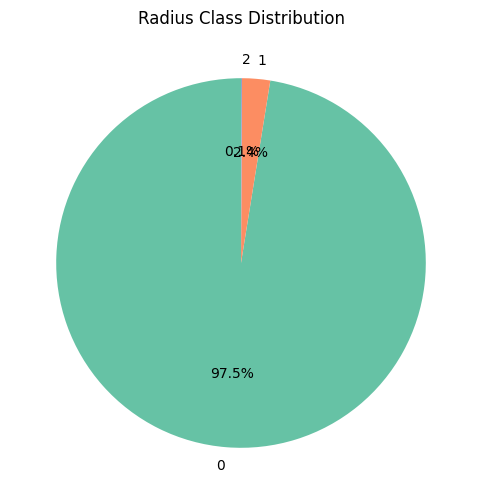

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts = BALBc_1_2["radius_class"].value_counts().sort_index()

labels = class_counts.index.astype(str)

colors = sns.color_palette("Set2")

plt.figure(figsize=(6,6))

plt.pie(
    class_counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Radius Class Distribution")

plt.show()